### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

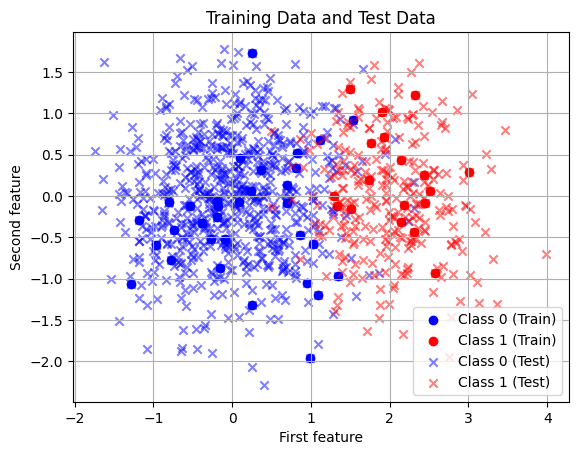

In [48]:

import numpy as np
import matplotlib.pyplot as plt

def generate_data(N, epsilon, p):
    # Define parameters
    mu0 = np.array([0, 0])
    mu1 = np.array([epsilon, 0])
    sigma0 = np.array([[0.5, 0], [0, 0.5]])
    sigma1 = np.array([[0.4, 0], [0, 0.4]])
    
    X = np.zeros((N, 2))
    y = np.zeros(N)
    
    seed = 15
    np.random.seed(seed)

    for i in range(N):
        # Step 1: Sample label y_i
        if np.random.rand() < p:
            y[i] = 1
            # Step 2: Sample x_i given y=1
            X[i] = np.random.multivariate_normal(mu1, sigma1)
        else:
            y[i] = 0
            # Step 2: Sample x_i given y=0
            X[i] = np.random.multivariate_normal(mu0, sigma0)
            
    return X, y

# Create our datasets
X_train, y_train = generate_data(50, 2, 0.3)
X_test, y_test = generate_data(1000, 2, 0.3)

# Visualize the training data
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='blue', label='Class 0 (Train)', marker='o', alpha=1)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', label='Class 1 (Train)', marker='o', alpha=1)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='blue', label='Class 0 (Test)', marker='x', alpha=0.5)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='red', label='Class 1 (Test)', marker='x', alpha=0.5)
plt.title('Training Data and Test Data')
plt.xlabel('First feature')
plt.ylabel('Second feature')
plt.legend()
plt.grid()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

Define the following ratio
$$r(x_0) = \frac{\text{Prob}(Y = 1 \mid \mathbf{x})}{\text{Prob}(Y = 0 \mid \mathbf{x})} = \frac{\frac{P(X|Y=1)P(Y=1)}{P(x_0)}}{\frac{P(X|Y=0)P(Y=0)}{P(x_0)}}$$
$$ = \frac{P(X|Y=1)P(Y=1)}{P(X|Y=0)P(Y=0)} =  \frac{P(X|Y=1)p}{P(X|Y=0)(1-p)} = \frac{3}{7} \frac{P(X|Y=1)}{P(X|Y=0)} $$
Thus when we have
$$r(x_0) = \frac{3}{7} \frac{P(X|Y=1)}{P(X|Y=0)}  \geq 1$$
the Bayes classifier must assign class $1$ to the point $x_0$. Hence for our case we can write

$$f(x) = \mathbf{1}(r(x_0)\geq 1) = 

\begin{array}{ll}
      1 & 3P(X|Y=1) \geq 7P(X|Y=0) \\
      0  & \text{otherwise} \\
\end{array} 
$$

and for a general p

$$f(x) = \mathbf{1}(r(x_0)\geq 1) = 

\begin{array}{ll}
      1 & pP(X|Y=1) \geq (1-p)P(X|Y=0) \\
      0  & \text{otherwise.} \\
\end{array} 
$$

And so the boundary region for our case is then 
$$ \mathcal{R} = \{ X \in \mathbb{R}^2 \: : \: 3 P(X|Y=1) = 7 P(X|Y=0) \} $$

and for a general p
$$ \mathcal{R} = \{ X \in \mathbb{R}^2 \: : \: pP(X|Y=1) = (1-p)P(X|Y=0) \}. $$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

We would expect the Bayes error rate to decrease when epsilon increases. Epsilon is the expected value for the first feature x1 of the samples of x when y=1. The second feature x2 have the expected value 0 for both classes. So when epsilon is zero both classes have the same expected value and can only be distinguished by their slightly different variances which makes them very hard to separate and this would give the highest error rate. When epsilon increases the samples with x when y=1 will move to the right on the x1 axis and this would make it easier to tell the classes apart, so the error rate approaches 0.

In [ ]:
from sklearn.base import ClassifierMixin
from scipy.stats import multivariate_normal

class BayesClassifier(ClassifierMixin):

    def __init__(self, epsilon=2, p=0.3):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y): #Fit doesn't use X or y but have them to follow the same logic as scikit-learn
        #Parameters for P(X|Y=0) for this setup
        self.mu0 = np.array([0, 0])
        self.sigma0 = np.array([[0.5, 0], [0, 0.5]])
        #Parameters for P(X|Y=1) for this setup
        self.mu1 = np.array([self.epsilon, 0])
        self.sigma1 = np.array([[0.4, 0], [0, 0.4]])
        
        # Return the classifier
        return self

    def predict(self, X):
        #Calculate P(X|Y=0) with the pdf
        P_x_y0 = multivariate_normal.pdf(X, mean=self.mu0, cov=self.sigma0)
        #Calculate P(X|Y=1) with the pdf
        P_x_y1 = multivariate_normal.pdf(X, mean=self.mu1, cov=self.sigma1)
        #Return 1 or 0 as seen in the formula in (b)
        return (self.p * P_x_y1 >= (1-self.p) * P_x_y0).astype(int)

In [50]:
X, y = generate_data(10000, 2, 0.3)
bayes_model = BayesClassifier()
bayes_model.fit(X,y) #Fit doesn't use X or y but have it to follow the same logic as scikit-learn
error_rate = 1 - bayes_model.score(X, y)
print(f"Bayes error rate for D(10^4, 2, 0.3): {error_rate:.4f} ({error_rate*100:.2f}%)")

Bayes error rate for D(10^4, 2, 0.3): 0.0681 (6.81%)


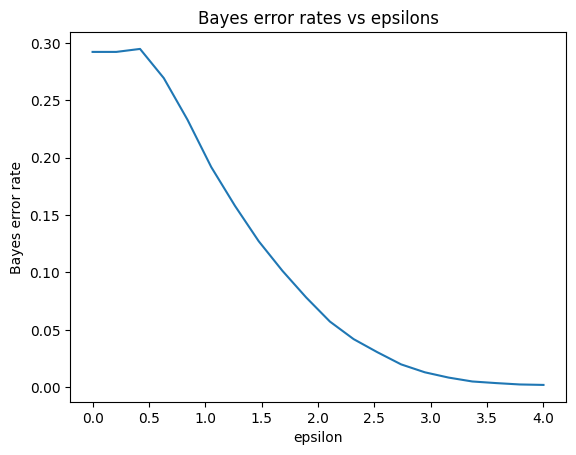

In [51]:
epsilons = np.linspace(0, 4, 20) 
error_rates = []

#Create datasets with different epsilon, classify them and calculate the Bayes error rate for them
for e in epsilons:
    X, y = generate_data(10000, e, 0.3)
    model = BayesClassifier(epsilon=e)
    model.fit(X,y)
    error_rates.append(1-model.score(X, y))

plt.plot(epsilons, error_rates)
plt.xlabel('epsilon')
plt.ylabel('Bayes error rate')
plt.title('Bayes error rates vs epsilons')
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

The datasets are generated by two groups with a gaussian distrubution and the two groups have slightly different variances (0.5 and 0.4).

Logistic Regression does not care about the groups distrubutions at all, it simply tries to fit the best straight line based on the math of the log-odds. It doesn't use the useful information we have about the data being gaussian and their variances. Linear Discriminant Analysis (LDA) assumes that both groups are gaussian and share the exact same variance. Because it assumes the groups are identical in shape, it draws a simple straight line to separate them. Quadratic Discriminant Analysis (QDA) also assumes the groups are gaussian and QDA allows them to have different variances, allowing it to draw a curved boundary that better fits the different spreads of the two groups. This makes QDA the most adequate choice here, as its assumption matches the generated datasets. 

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [52]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

print(f"Bayes error rate from (c): {error_rate:.4f} ({error_rate*100:.2f}%)")

bayes_model = BayesClassifier(epsilon=2, p=0.3)
bayes_model.fit(X_train, y_train)
bayes_error = 1 - bayes_model.score(X_test, y_test)
print(f"Bayes error rate for Dtest: {bayes_error:.4f} ({bayes_error*100:.2f}%)")

LDAmodel = LinearDiscriminantAnalysis()
LDAmodel.fit(X_train,y_train)
print(f"Test error rate for LDA for Dtest: {1-LDAmodel.score(X_test, y_test):.4f} ({(1-LDAmodel.score(X_test, y_test))*100:.2f}%)")

QDAmodel = QuadraticDiscriminantAnalysis()
QDAmodel.fit(X_train,y_train)
print(f"Test error rate for QDA for Dtest: {1-QDAmodel.score(X_test, y_test):.4f} ({(1-QDAmodel.score(X_test, y_test))*100:.2f}%)")

LRmodel = LogisticRegression()
LRmodel.fit(X_train,y_train)
print(f"Test error rate for Logistic Regression Classifier for Dtest: {1-LRmodel.score(X_test, y_test):.4f} ({(1-LRmodel.score(X_test, y_test))*100:.2f}%)")

Bayes error rate from (c): 0.0681 (6.81%)
Bayes error rate for Dtest: 0.0530 (5.30%)
Test error rate for LDA for Dtest: 0.0600 (6.00%)
Test error rate for QDA for Dtest: 0.0720 (7.20%)
Test error rate for Logistic Regression Classifier for Dtest: 0.0670 (6.70%)


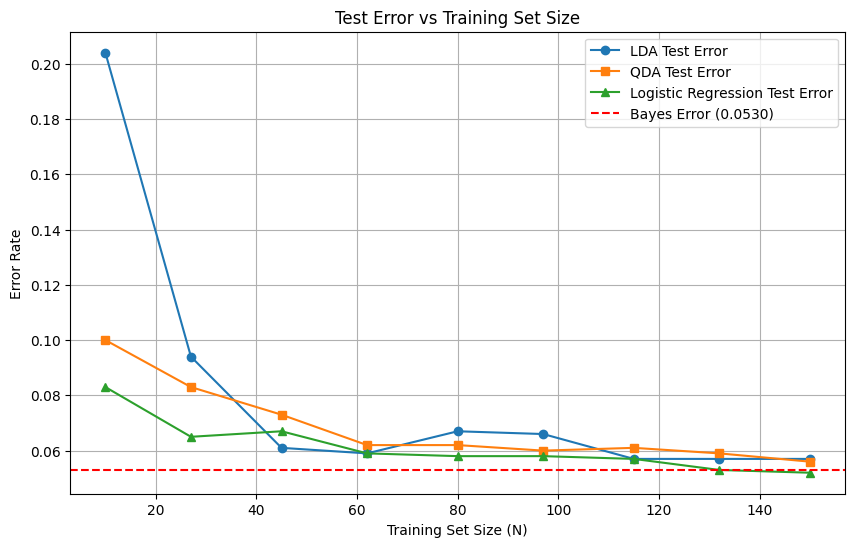

In [53]:
#Number of samples in Dtrain
N_values = np.linspace(10, 150, 9, dtype=int)
ldaerrors = []
qdaerrors = []
lrerrors = []

for N in N_values:
    X_train_N, y_train_N = generate_data(N, 2, 0.3)
    
    #Train LDA
    LDAmodel.fit(X_train_N, y_train_N)
    ldaerrors.append(1 - LDAmodel.score(X_test, y_test))
    
    #Train QDA
    QDAmodel.fit(X_train_N, y_train_N)
    qdaerrors.append(1 - QDAmodel.score(X_test, y_test))
    
    #Train Logistic Regression
    LRmodel.fit(X_train_N, y_train_N)
    lrerrors.append(1 - LRmodel.score(X_test, y_test))

#Plot
plt.figure(figsize=(10, 6))
plt.plot(N_values, ldaerrors, label='LDA Test Error', marker='o')
plt.plot(N_values, qdaerrors, label='QDA Test Error', marker='s')
plt.plot(N_values, lrerrors, label='Logistic Regression Test Error', marker='^')
#Bayes doesn't depend on the training data, so we can use the same value for all N
plt.axhline(y=bayes_error, color='r', linestyle='--', label=f'Bayes Error ({bayes_error:.4f})')
plt.xlabel('Training Set Size (N)')
plt.ylabel('Error Rate')
plt.title('Test Error vs Training Set Size')
plt.legend()
plt.grid(True)
plt.show()

When comparing the classifiers to the value obtained in (c) (6.81%), they actually performed well, with LDA (6.00%) and Logistic Regression (6.70%) achieving lower error rates. However, when comparing them to the Bayes Error calculated on the test set, the Bayes error was 5.30% and all the other classifiers performed worse. This difference is probably because the specific random sampling of the test set was easier, it had less overlap between the classes, than the larger dataset used in part (c).

Theoretically, as the training set size N increases, the estimation variance of the classifiers decreases so the gap between the Bayes error rate and test error for each classifier will decrease. With more data points, the models have more evidence to accurately estimate their parameters. This makes the decision boundaries more stable. If a model’s structural assumptions match the data-generating process, its test error will converge toward the Bayes Error as N grows.

Empirically, we observe that all classifiers improve as N increases, suggesting that the underlying Gaussian pattern is relatively straightforward for these models to learn when they have enough data points in the tranining set. For this dataset, QDA is the model with the right structural assumptions is the only model among the three that can perfectly capture the true quadratic boundary. In the beginning QDA requires more data to stabilize because it is more complex so it has more parameters to learn. However, since the variances are relatively similar ($0.5$ and $0.4$), the true boundary is only slightly curved. This explains why LDA and Logistic Regression perform so well, a linear boundary captures the pattern of this specific test set very well. 

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [54]:
# Generate the D'_test set
D_prime = generate_data(1000, 0.5, 0.7)

X_test_prime, y_test_prime= D_prime

print(f"Test error rate for Bayes (on D'): {1-bayes_model.score(X_test_prime, y_test_prime):.4f} ({(1-bayes_model.score(X_test_prime, y_test_prime))*100:.2f}%)")

print(f"Test error rate for LDA (on D'): {1-LDAmodel.score(X_test_prime, y_test_prime):.4f} ({(1-LDAmodel.score(X_test_prime, y_test_prime))*100:.2f}%)")

print(f"Test error rate for QDA (on D'): {1-QDAmodel.score(X_test_prime, y_test_prime):.4f} ({(1-QDAmodel.score(X_test_prime, y_test_prime))*100:.2f}%)")

print(f"Test error rate for Logistic Regression Classifier (on D'): {1-LRmodel.score(X_test_prime, y_test_prime):.4f} ({(1-LRmodel.score(X_test_prime, y_test_prime))*100:.2f}%)")


Test error rate for Bayes (on D'): 0.6070 (60.70%)
Test error rate for LDA (on D'): 0.5960 (59.60%)
Test error rate for QDA (on D'): 0.6050 (60.50%)
Test error rate for Logistic Regression Classifier (on D'): 0.6190 (61.90%)


When testing on the new dataset, the error rates jumps from around 6% to around 60%. $\varepsilon$ was reduced from 2 to 0.5 and $\varepsilon$ determined how far the center of the two groups of data were so they're now much closer together. p also increased from 0.3 to 0.7 and p is the class balance. This means Class 1 is now the majority instead of the minority. The models are still using the decision boundaries they learned from the original training data, where the classes were far apart and Class 1 was rare. We did not retrain them on this new distribution so their expectations about where the boundary should be and which class is more common are now completely wrong on the new test data. Therefore they are systematically making the wrong assumptions about which class is which and performs even worse than a random guess.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

We tried to do some exploration and feature engineering on our own, as well as tried the pipelines from Skrub. Our findings are presented under the titles "Exploratory Data Analysis and Feature Engineering" and "Predictor Encoding in Skrub" in the below text (after answer to (b)). 

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

**Kaggle Scores:**

With "manual" feature engineering : 

- Random Forest: 0.77511
- HistGradientBoosting: 0.76076 

With skrub feature engineering :
- tabular_pipeline (skrub feature engineering via TableVectorizer followed by HistGradientBoosting): 0.80382

For reference the gender_submission.csv scores 0.76555. This is the score of a model which simply assumes every woman of the test set survived and every man did not. However, HistGradientBoosting here is not even performing better than such model. It is possible that this gradient boosted model is overfitting to the residual errors of the training data. If this is the case then parameter fine-tuning to obtain the best accuracy likely is exacerbating the problem. This hypothesis is consistent with RandomForest performing better as it is general unlikely that a RandomForest model would overfit ( = ensemble of decorrelated trees creates average learner with lower variance).

However, in the end, tabular_pipeline outperformed both RandomForest and HistGradientBoosting (both with manual feature engineering), without parameter tuning (for e.g. the cardinality threshold values that define low_cardinality and high_cardinality in the TableVectoriser feature engineering function). The justification for tabular_pipeline is that it is specifically designed for rich, diverse tabular data including text and/or categorical columns. This is exactly what we can see in the titanic dataset (i.e. hetergeneous data with multiple types in tabular form). 


Note now the the following which are the results for tabular_pipeline using 4 different classifiers:
- (default)  tabular_pipeline(HistGradientBoosting): 0.80382 (as above)
- tabular_pipeline(best_hg): 0.77511
- tabular_pipeline(RandomForestClassifier): 0.78229
- tabular_pipeline(best_rf): 0.76555

Hence we can conclude that tabular_pipeline performed best in the scenarios where its final classifier did not have fine-tuned parameters. 


# Exploratory Data Analysis and Feature Engineering

In [192]:
import pandas as pd
import numpy as np


training = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [193]:
training.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [194]:
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Null Values
The above shows null values in the Age, Cabin and Embarked columns. 

#### Heterogeneity of data
Multiple data types: int64, object, float64

In [195]:
training.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Missing Values: The data is of three different data types: object, int64 and float64. There are 2 missing values in Embarked and 177 missing values in Age. For Cabin we only have data for 204 out of the 891 entries.

Since we are missing almost 80% of the data for Cabin, we will unfortunately drop that column. Most passengers had gone to bed before the impact with the iceberg, so it is possible that this predictor is valuable, but there is too little data to complete the dataset. We will replace the missing Age values by the median age, and the missing Embarked values with the most common port. The categorical data like Sex and Embarked will be one-hot encoded.

In [196]:
#Find most common port:
value_counts = training.value_counts('Embarked')
value_counts


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [197]:
#Data Cleaning and Data Drop Process
training['Age'] = training['Age'].fillna(training['Age'].dropna().median())
# Change categorical data to numerical data
training['Sex'] = training['Sex'].map({'male': 0, 'female': 1})

# change the 2 null values to S then assign numerical values to the categoric column
training['Embarked']=training['Embarked'].fillna('S') #Most common port
training['Embarked'] = training['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Drop the columns that we won't be using for classification
training = training.drop(columns=['Name', 'Ticket', 'Cabin'])


In [198]:
training.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


In [161]:
# Do the same for the test set
test['Age'] = test['Age'].fillna(test['Age'].dropna().median())
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})
test['Embarked']=test['Embarked'].fillna('S')
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test = test.drop(columns=['Name', 'Ticket', 'Cabin'])

In [199]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


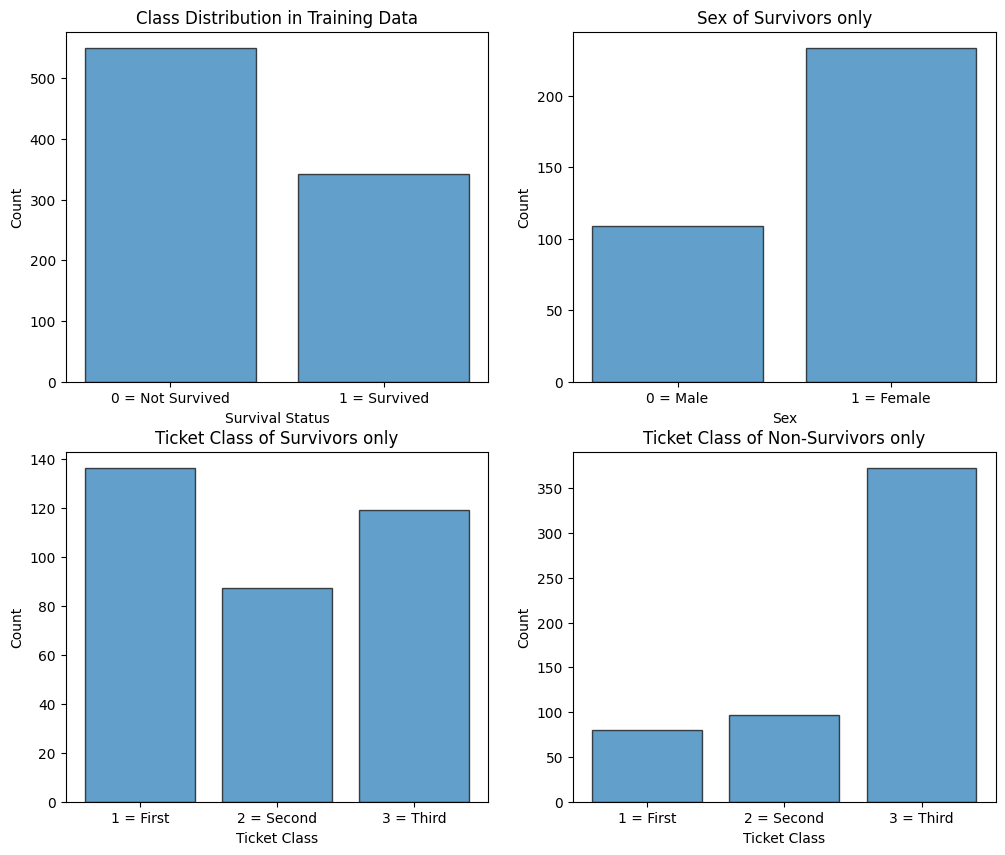

Number of samples in each class:
Survived
0    549
1    342
Name: count, dtype: int64
Proportion of each class:
Survived
0    0.616162
1    0.383838
Name: count, dtype: float64


In [200]:
# Check the class distribution
fig, ax = plt.subplots(2,2, figsize=(12, 10))
class_counts = training['Survived'].value_counts().sort_index()
sex_of_survivors = training.groupby('Survived')['Sex'].value_counts().unstack().fillna(0)
class_of_survivors = training.groupby('Survived')['Pclass'].value_counts().unstack().fillna(0)


ax[0,0].bar([0, 1], class_counts, edgecolor='black', alpha=0.7)
ax[0,0].set_xticks([0, 1])
ax[0,0].set_xticklabels(['0 = Not Survived', '1 = Survived'])
ax[0,0].set_xlabel('Survival Status')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Class Distribution in Training Data')

ax[0,1].bar([0, 1], sex_of_survivors.loc[1], edgecolor='black', alpha=0.7)
ax[0,1].set_xticks([0, 1])
ax[0,1].set_xticklabels(['0 = Male', '1 = Female'])
ax[0,1].set_xlabel('Sex')
ax[0,1].set_ylabel('Count')
ax[0,1].set_title('Sex of Survivors only')

ax[1,0].bar([1, 2, 3], class_of_survivors.loc[1], edgecolor='black', alpha=0.7)
ax[1,0].set_xticks([1, 2, 3])
ax[1,0].set_xticklabels(['1 = First', '2 = Second', '3 = Third'])
ax[1,0].set_xlabel('Ticket Class')
ax[1,0].set_ylabel('Count')
ax[1,0].set_title('Ticket Class of Survivors only')

ax[1,1].bar([1, 2, 3], class_of_survivors.loc[0], edgecolor='black', alpha=0.7)
ax[1,1].set_xticks([1, 2, 3])
ax[1,1].set_xticklabels(['1 = First', '2 = Second', '3 = Third'])
ax[1,1].set_xlabel('Ticket Class')
ax[1,1].set_ylabel('Count')
ax[1,1].set_title('Ticket Class of Non-Survivors only')

plt.show()

print(f"Number of samples in each class:\n{class_counts}")
print(f"Proportion of each class:\n{class_counts / class_counts.sum()}")

Total number of men = 577

Total number of women = 314

A larger proportion of women survived than men even though there were many less women on boad the ship. This suggests Sex may be an important predictor. The distribution between ticket class among the survivors is less uneven than we expected. However, most non-survivors hold a third class ticket.

In [201]:
# check columns remaining and their names
training.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')

Cross Validation Options The dataset is ordered based on passenger id. We dropped Name, Ticket and Cabin from our dataset, so those possible sources of IID are no longer there. The dataset is slightly imbalanced on survivors and non-survivors, so we could use stratified k-fold to ensure this target balance is kept during the cross-validation.

# Boosted Decision Tree

In [202]:
# import tools from sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

random_state = 42


# Prepare the data for training
features = training.drop(columns=['Survived'])
target = training['Survived']

# Split the data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=random_state)

In [178]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# define the parameter grid
params = {       'max_depth' : [4, 6, 8],
                 'n_estimators': [50, 10],
                 'max_features': ['sqrt', 'log2'],
                 'min_samples_split': [2, 3, 10],
                 'min_samples_leaf': [1, 3, 10],
                 'bootstrap': [True, False]}

# Create Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=random_state)

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=params,
    cv=StratifiedKFold(n_splits=5),  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all processors
    verbose=1
)

# Fit the grid search
grid_search.fit(features, target)

# Display results
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_rf = grid_search.best_estimator_


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'bootstrap': True, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 10}
Best Cross-Validation Score: 0.8328


In [174]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Define the parameter grid for HistGradientBoostingClassifier
hg_param_grid = {
    'max_iter': [50, 100, 150, 200],
    'learning_rate': [0.001, 0.01, 0.02],
    'max_depth': [3, 4, 5, 7],
    'min_samples_leaf': [1, 5, 10, 15],
    'max_leaf_nodes': [25, 35],
    'l2_regularization': [0, 0.01, 0.1]
}

# Create Gradient Boosting classifier
hg_classifier = HistGradientBoostingClassifier(random_state=random_state)

# Perform Grid Search with cross-validation
hg_grid_search = GridSearchCV(
    estimator=hg_classifier,
    param_grid=hg_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all processors
    verbose=1
)

# Fit the grid search
hg_grid_search.fit(features, target)

# Display results
print(f"\nBest Parameters: {hg_grid_search.best_params_}")
print(f"Best Cross-Validation Score: {hg_grid_search.best_score_:.4f}")

# define the best estimator
best_hg = hg_grid_search.best_estimator_

Fitting 5 folds for each of 1152 candidates, totalling 5760 fits

Best Parameters: {'l2_regularization': 0, 'learning_rate': 0.01, 'max_depth': 7, 'max_iter': 150, 'max_leaf_nodes': 35, 'min_samples_leaf': 15}
Best Cross-Validation Score: 0.8350


# Using skrub for feature engineering and then tabular_pipline 

In [179]:
# Reimport data to use skrub
training_skrub = pd.read_csv('train.csv')
test_skrub = pd.read_csv('test.csv')

# Define the features and target for skrub
features_skrub = training_skrub.drop(columns=['Survived'])
target_skrub = training_skrub['Survived']

# Do a train test split for skrub
X_train_skrub, X_test_skrub, y_train_skrub, y_test_skrub = train_test_split(features_skrub, target_skrub, test_size=0.3, random_state=random_state)

In [180]:
from skrub import tabular_pipeline

pipeline = tabular_pipeline('classification')

pipeline.fit(X_train_skrub, y_train_skrub)
pipeline.predict(X_test_skrub)

print("Accuracy of skrub tabular pipeline = ", accuracy_score(pipeline.predict(X_test_skrub), y_test_skrub))

Accuracy of skrub tabular pipeline =  0.835820895522388


In [181]:
# fit the pipeline on the skrub features and target
pipeline.fit(features_skrub, target_skrub)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tablevectorizer', ...), ('histgradientboostingclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cardinality_threshold,40
,low_cardinality,ToCategorical()
,high_cardinality,StringEncoder()
,numeric,PassThrough()
,datetime,DatetimeEncoder()
,specific_transformers,()
,drop_null_fraction,1.0


### Predictor Encoding in Skrub
As found earlier, we have predictors of the three datatypes object, int64 and float64. The tabular_pipeline from Skrub cleans the data in the TableVectorizer to ensure that they are all numerical datatypes of type float32. The default transformer for numeric values (like our int64 and float64) is "passthrough", so nothing will happen to them except that they will be recasted as float32.

Our object datatype will be handled differently depending on the cardinality (= how many different unique values there are). The default threshold for high cardinality is 40. This means that Name, Ticket and Cabin will be considered high cardinality and Sex and Embarked as low cardinality. The default transformer is a one-hot encoder for low cardinality and string encoder for high.

One issue is that Pclass is a categorical predictor of datatype int64. This needs to be specially handled to ensure that the pipeline will treat it correctly.

The tabular_pipeline handles missing values for us. If the classifier can handle missing values itself (like the HistGradientBoostingClassifier), it lets it do that, and if the classifier does not (like LogisticRegression), it will add a SimpleImputer to do the job.

# Generating y_predictions using our 3 fitted models

In [191]:
# Predict on test set using best of each model
y_pred_skrub = pipeline.predict(test_skrub)

y_pred_rf = best_rf.predict(test)

y_pred_hg = best_hg.predict(test)

In [183]:
pred_rf = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": y_pred_rf})
pd.DataFrame.to_csv(pred_rf, "pred_rf.csv", index=False)

pred_hg = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": y_pred_hg})
pd.DataFrame.to_csv(pred_hg, "pred_hg.csv", index=False)

pred_skrub = pd.DataFrame({"PassengerId": test_skrub["PassengerId"], "Survived": y_pred_skrub})
pd.DataFrame.to_csv(pred_skrub, "pred_skrub.csv", index=False)

In [224]:
pipeline = tabular_pipeline(best_hg)

pipeline.fit(features_skrub, target_skrub)
y_pred_skrub_hg = pipeline.predict(test_skrub)

pred_skrub_hg = pd.DataFrame({"PassengerId": test_skrub["PassengerId"], "Survived": y_pred_skrub_hg})
pd.DataFrame.to_csv(pred_skrub_hg, "pred_skrub_hg.csv", index=False)